In [139]:
from calendar import monthrange
from datetime import datetime

import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from get_collections_and_files import list_files_and_excluded_vars

# First from the TUI, choose one data chunk you want to test

# inputs you choose
model = "geosfp"          # table name, e.g. "geosfp"
year = 2024
month = 2  
day = 1
#id_string = "inst1_2d_hwl_Nx|CO2CL|None|Strat1"
id_string = "inst3_3d_aer_Nv|BCPHILIC|8.0|Strat2"
#"inst3_3d_aer_Nv|MSA|10.0|Strat7"

In [140]:
# extract collection, etc, ..

Strata_dict = {
    "Strat1": {
        "lat": {"min": -90, "max": -70},
    },
    "Strat2": {
        "lat": {"min": -70, "max": -45},
    },
    "Strat3": {
        "lat": {"min": -45, "max": -20},
    },
    "Strat4": {
        "lat": {"min": -20, "max": 0},
    },
    "Strat5": {
        "lat": {"min": 0, "max": 20},
    },
    "Strat6": {
        "lat": {"min": 20, "max": 45},
    },
    "Strat7": {
        "lat": {"min": 45, "max": 70},
    },
    "Strat8": {
        "lat": {"min": 70, "max": 90},
    },
}

def parse_id_string(id_string: str, strata_dict: dict) -> dict:
    parts = id_string.split("|")
    if len(parts) != 4:
        raise ValueError(
            f"id_string must have 4 fields separated by '|', got: {id_string}"
        )

    collection, var, level_str, stratum = parts

    try:
        level = float(level_str)
    except ValueError as e:
        raise ValueError(f"Could not parse level from '{level_str}'") from e

    if stratum not in strata_dict:
        raise KeyError(f"Stratum '{stratum}' not found in Strata_dict")

    lat_info = strata_dict[stratum].get("lat")
    if lat_info is None:
        raise KeyError(f"No 'lat' entry found for stratum '{stratum}'")

    lat_min = lat_info["min"]
    lat_max = lat_info["max"]

    return {
        "collection": collection,
        "var": var,
        "level": level,
        "stratum": stratum,
        "lat_min": lat_min,
        "lat_max": lat_max,
    }


In [141]:
parsed = parse_id_string(id_string, Strata_dict)

collection = parsed["collection"]
var = parsed["var"]
level = parsed["level"]
stratum = parsed["stratum"]
lat_min = parsed["lat_min"]
lat_max = parsed["lat_max"]

print("Extracted values:")
print(f"collection = {collection}")
print(f"var        = {var}")
print(f"level      = {level}")
print(f"stratum    = {stratum}")
print(f"lat_min    = {lat_min}")
print(f"lat_max    = {lat_max}")

Extracted values:
collection = inst3_3d_aer_Nv
var        = BCPHILIC
level      = 8.0
stratum    = Strat2
lat_min    = -70
lat_max    = -45


In [142]:
# connect to the database and verify that the t-digest displayed by the TUI for this
# id_string is correct

import sqlite3, pickle, pathlib

db = "/home/sadhika8/JupyterLinks/nobackup/quads_database/geosfp_monthly_aggregated_centroids_and_quantiles.db"
with sqlite3.connect(db) as conn:
    cur = conn.cursor()
    #cur.execute("SELECT COUNT(*) FROM geosfp;")
    #print("rows:", cur.fetchone()[0])

    cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
    tables = [row[0] for row in cur.fetchall()]

    print("tables:", tables)

    for t in tables:
        cur.execute(f"PRAGMA table_info({t});")
        cols = [row[1] for row in cur.fetchall()]  # row[1] is column name
        print(f"{t} columns: {cols}")

tables: ['geosfp']
geosfp columns: ['model', 'year', 'month', 'id_string', 'compression', 'centroids', 'quantiles', 'quantile_list']


In [143]:
with sqlite3.connect(db) as conn:
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()

    cur.execute(
        f"""
        SELECT *
        FROM {model}
        WHERE year = ?
          AND month = ?
          AND id_string = ?
        LIMIT 1
        """,
        (year-1, month, id_string),
    )

    row = cur.fetchone()
    if row is None:
        print("No match found.")
    else:
        d = dict(row)
        print("Matched row keys:", list(d.keys()))

        y, x = d["quantiles"], d["quantile_list"]
        if isinstance(y, (bytes, bytearray)): y = pickle.loads(y)
        if isinstance(x, (bytes, bytearray)): x = pickle.loads(x)

Matched row keys: ['model', 'year', 'month', 'id_string', 'compression', 'centroids', 'quantiles', 'quantile_list']


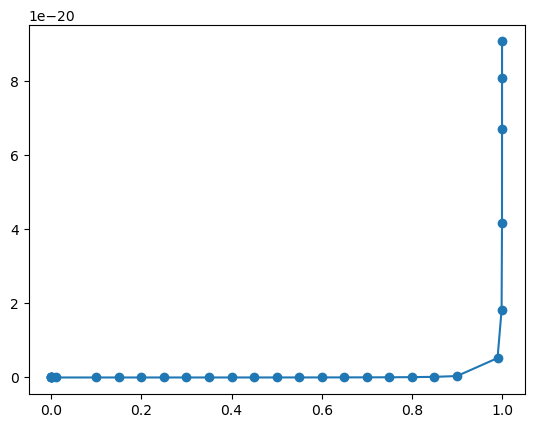

In [144]:
plt.scatter(x, y)
plt.plot(x, y)

In [145]:
from sanity_check_v2 import fence
fence_low, fence_high = fence((y, x))
print(fence_low, fence_high)

# fence_low and fence_high outputted here must match exactly to the values shown by the TUI

-1.0884763190294584e-24 1.7925381228260856e-19


In [146]:
# Now, access the daily consolidated raw data for that chunk and verify that the number
# of data points above and below the computed fence can be computed here
# histogram and summary stats are optional

def daily_histogram_for_collection(
    model,
    date,
    collection,
    var,
    data_yaml_file,
    lat_name="lat",
    lev_name="lev",
    lat_min=None,
    lat_max=None,
    level=None,
    bins=100,
    fence_low=None,
    fence_high=None,
):
    all_files = []
    excluded = []

    _, collection_map, excluded_vars = list_files_and_excluded_vars(
        model=model,
        date=date,
        data_yaml_file=data_yaml_file,
    )

    all_files.extend(collection_map.get(collection, []))

    if not excluded:
        excluded = excluded_vars

    print(f"Found {len(all_files)} files for collection {collection} on {date:%Y-%m-%d}")

    if not all_files:
        raise RuntimeError(
            f"No files found for collection={collection} on date={date:%Y-%m-%d}"
        )

    ds = xr.open_mfdataset(
        all_files,
        combine="by_coords",
        drop_variables=excluded,
        data_vars="minimal",
        coords="minimal",
        compat="no_conflicts",
        engine="h5netcdf",
        chunks="auto",
        parallel=True,
    )

    da_var = ds[var]

    lat_vals = da_var[lat_name].values
    if lat_vals[0] <= lat_vals[-1]:
        da_var = da_var.sel({lat_name: slice(lat_min, lat_max)})
    else:
        da_var = da_var.sel({lat_name: slice(lat_max, lat_min)})

    if level is not None and lev_name in da_var.dims:
        da_var = da_var.sel({lev_name: level})

    arr = da_var.data
    arr = da.where(da.isfinite(arr), arr, np.nan)

    n = da.sum(~da.isnan(arr)).compute()
    mean_val = da.nanmean(arr).compute()
    std_val = da.nanstd(arr).compute()
    min_val = da.nanmin(arr).compute()
    max_val = da.nanmax(arr).compute()

    print("N:", int(n))
    print("mean:", float(mean_val))
    print("std:", float(std_val))
    print("min:", float(min_val))
    print("max:", float(max_val))

    flat = arr.ravel()
    finite_vals = flat[da.isfinite(flat)]

    if fence_low is not None and fence_high is not None:
        left_violations = (finite_vals < fence_low).sum().compute()
        right_violations = (finite_vals > fence_high).sum().compute()
        print("left_violations:", int(left_violations))
        print("right_violations:", int(right_violations))
        print(left_violations + right_violations)

    hist, bin_edges = da.histogram(
        finite_vals,
        bins=bins,
        range=(float(min_val), float(max_val)),
    )
    hist = hist.compute()

    plt.figure()
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align="edge")
    plt.title(f"Histogram: {var} ({date:%Y-%m-%d})")
    plt.xlabel(var)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2024/M02/D01
Found 8 files for collection inst3_3d_aer_Nv on 2024-02-01
N: 930816
mean: 2.8747361641637693e-21
std: 2.794022884982914e-20
min: 5.100051696095137e-26
max: 1.8486272803011247e-18
left_violations: 0
right_violations: 2705
2705


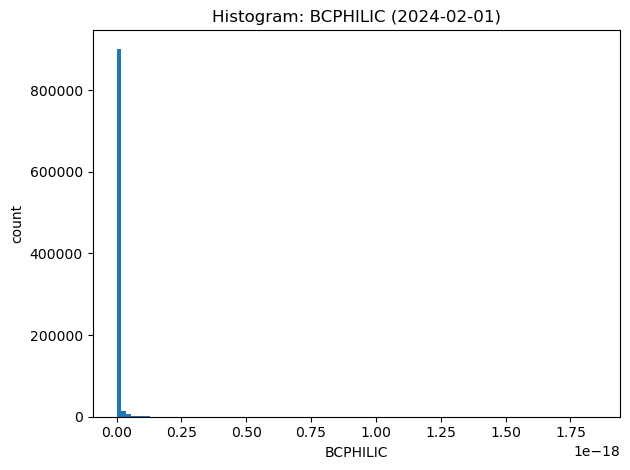

In [147]:
from datetime import datetime

daily_histogram_for_collection(
    model=model.upper(),
    date=datetime(year, month, day),
    collection= collection, #"inst3_3d_aer_Nv", #"inst1_2d_hwl_Nx","inst3_3d_aer_Nv|BCPHILIC|8.0|Strat2"
    var= var, #"BCPHILIC", #"CO2CL",
    data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/dataserver.yaml",
    lat_name="lat",
    lat_min= lat_min, #-90,
    lat_max= lat_max, #-70,
    level= level, # None
    bins=100,
    fence_low=fence_low,
    fence_high=fence_high,
)

In [148]:
# now analyze the monthly reference data itself
# compute histogram
# compute t-digest and fence -- it has to match exactly to what the TUI displays

In [150]:
from calendar import monthrange

def monthly_data_for_collection(
    model,
    year,
    month,
    collection,
    var,
    data_yaml_file,
    lat_name="lat",
    lev_name="lev",
    lat_min=None,
    lat_max=None,
    level=None,
):
    all_files = []
    excluded = []

    for day in range(1, monthrange(year, month)[1] + 1):
        _, collection_map, excluded_vars = list_files_and_excluded_vars(
            model=model,
            date=datetime(year, month, day),
            data_yaml_file=data_yaml_file,
        )

        all_files.extend(collection_map.get(collection, []))

        if not excluded:
            excluded = excluded_vars

    print(f"Found {len(all_files)} files for collection {collection}")

    if not all_files:
        raise FileNotFoundError(
            f"No files found for model={model}, year={year}, month={month}, collection={collection}"
        )

    ds = xr.open_mfdataset(
        all_files,
        combine="by_coords",
        drop_variables=excluded,
        data_vars="minimal",
        coords="minimal",
        compat="no_conflicts",
        engine="h5netcdf",
        chunks="auto",
        parallel=True,
    )

    da_var = ds[var]

    lat_coord = da_var[lat_name]
    if lat_coord[0] <= lat_coord[-1]:
        da_var = da_var.sel({lat_name: slice(lat_min, lat_max)})
    else:
        da_var = da_var.sel({lat_name: slice(lat_max, lat_min)})

    if level is not None and lev_name in da_var.dims:
        da_var = da_var.sel({lev_name: level})

    arr = da_var.data
    arr = da.where(da.isfinite(arr), arr, np.nan)

    return arr

In [151]:
arr = monthly_data_for_collection(
    model=model.upper(),
    year=year-1,
    month=month,
    collection=collection,#"inst3_3d_aer_Nv", #"inst1_2d_hwl_Nx", BCPHILIC
    var=var,#"BCPHILIC", #"CO2CL",
    data_yaml_file="/home/sadhika8/JupyterLinks/nobackup/quads/conf/dataserver.yaml",
    lat_name="lat",
    lev_name="lev",
    lat_min=lat_min,
    lat_max=lat_max,
    level=level,
)

GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D01
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D02
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D03
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D04
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D05
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D06
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D07
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D08
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D09
GEOS.fp.asm.*.%Y%m%d_%H%M.V01.nc
/discover/nobackup/projects/gmao/gmao_ops/pub/fp/das/Y2023/M02/D10


In [152]:
arr_np = arr.compute()
finite_vals = arr_np[np.isfinite(arr_np)]

n = finite_vals.size
mean = np.mean(finite_vals)
std = np.std(finite_vals)
min_val = np.min(finite_vals)
max_val = np.max(finite_vals)

print(f"N: {n}")
print(f"mean: {mean}")
print(f"std: {std}")
print(f"min: {min_val}")
print(f"max: {max_val}")

N: 26062848
mean: 2.5842906550197577e-22
std: 1.3667226976329863e-21
min: 9.79870785245449e-28
max: 9.618246782674053e-20


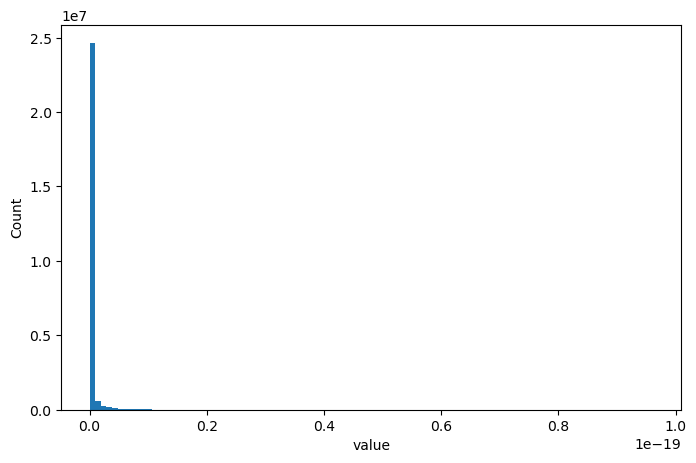

In [153]:
hist, bin_edges = np.histogram(finite_vals, bins=100)

plt.figure(figsize=(8, 5))
plt.bar(
    bin_edges[:-1],
    hist,
    width=np.diff(bin_edges),
    align="edge",
)
plt.xlabel("value")
plt.ylabel("Count")
#plt.title(f"Histogram of")
plt.show()

In [154]:
from pytdigest import TDigest
from test_make_digest import get_quantiles_from_tdigest

td = TDigest.compute(finite_vals, compression=300)

In [155]:
quantiles, quantile_list = get_quantiles_from_tdigest(td)

In [156]:
#print(quantiles)

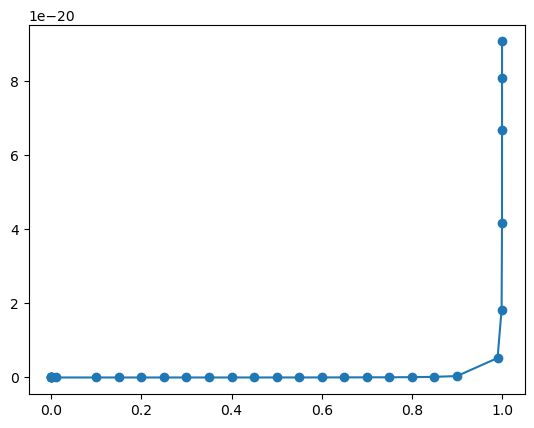

In [157]:
plt.plot(quantile_list, quantiles)
plt.scatter(quantile_list, quantiles)

In [158]:
fence_low, fence_high = fence((quantiles, quantile_list))
print(fence_low, fence_high)

-1.0555872596709984e-24 1.7910421882815035e-19


In [159]:
#for i, j in zip(quantile_list, quantiles):
#        print([i, j])

In [160]:
print(quantiles)

[1.0242985277084434e-27, 1.4125420837966014e-27, 2.2762744012513103e-27, 3.3956221234606474e-27, 6.278990176136254e-27, 1.857886575882259e-26, 1.2884402644248978e-25, 2.3795066722042343e-25, 4.2212763429422e-25, 7.077278517804186e-25, 1.1436009439772307e-24, 1.788078711534891e-24, 2.6881103583935702e-24, 4.148876813029272e-24, 6.3193517353581795e-24, 9.482379602126576e-24, 1.4158326900259728e-23, 2.1224414671889102e-23, 3.3550285301095825e-23, 5.323011360846724e-23, 8.797570579103406e-23, 1.7043025395931538e-22, 3.8157555287018395e-22, 5.244728312597018e-21, 1.825095301725883e-20, 4.1647697896068237e-20, 6.681613737708125e-20, 8.081043132529827e-20, 9.059130708657823e-20]
